<h1 align="center">Практическая работа№5</h1>

<h1 align="center">Задание на работу: </h1>

1. Сгенерируйте ряд из 500 значений
x[i+2] = x[i+1]*(2+dt*L*(1-x[i]**2))-x[i]*(1+dt**2+dt*L*(1-x[i]**2))+dt**2*sin(omega*i*dt), 
где x[0] = 0, x[1] = (-1)**k*dt, L=k/10, omega = 100/k, dt = 2*pi/1000, k - ваш номер в журнале.
2. Методом пакетного градиентного спуска подберите частоты (om) и коэффициенты (a,b) гармонического разложения из двух гармоник (семь параметров), аппроксимирующего функцию x[i]. Форма функции есть
X[i] = a0 + a1*cos(om1*i*dt) + b1*sin(om1*i*dt) + a2*cos(om2*i*dt) + b2*sin(om2*i*dt)
параметры a0, a1, a2, b1, b2, om1, om2.
3. Сделайте то же самое методом стохастического градиентного спуска. 
4. Подберите параметры спусков так, чтобы точности были приближенно равны (одного порядка). 
5. Сравните времена работы алгоритмов. 
6. Постройте на одном графике: рад из исходных 500 значений, приближение пакетным спуском, приближение стохастическим спуском.
7. Сделайте вывод о работе: какой вид градиентного спуска и при каких обстоятельствах имеет смысл применять, как подбирать настройки.

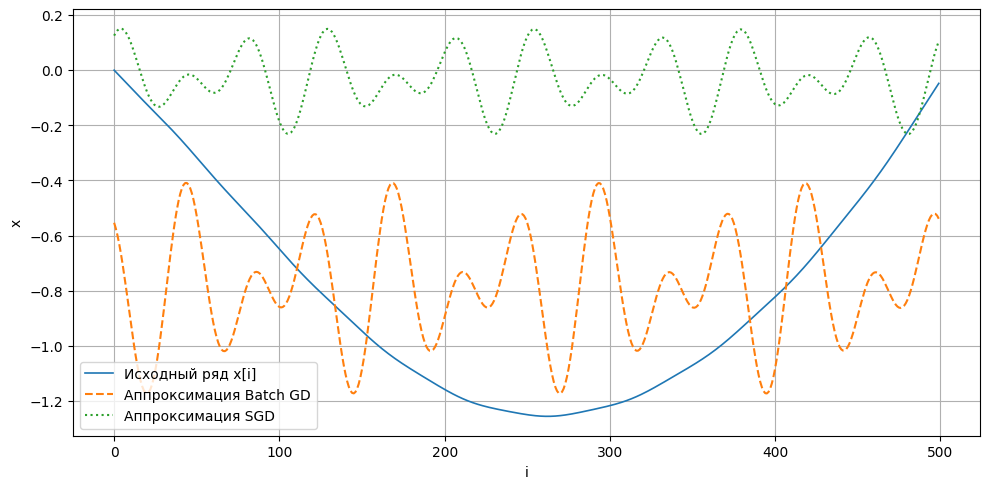

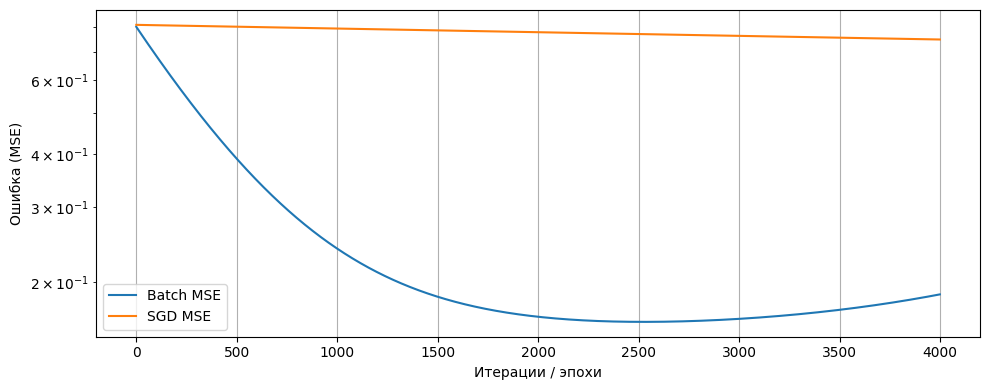

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import math
import time

#Мой номер в журнале
k = 5
N = 500
dt = 2 * math.pi / 1000
L = k / 10
omega = 100 / k

#Генерация ряда
x = np.zeros(N)
x[0] = 0.0
x[1] = (-1)**k * dt
for i in range(N - 2):
    x[i + 2] = (x[i + 1] * (2 + dt * L * (1 - x[i]**2))
            - x[i] * (1 + dt ** 2 + dt * L * (1 - x[i]**2))
            + dt**2 * math.sin(omega * i * dt))

i_array = np.arange(N)

#Градиентный спуск
def model(params, i_idx):
    a0, a1, a2, b1, b2, om1, om2 = params
    z1 = om1 * i_idx * dt
    z2 = om2 * i_idx * dt
    return a0 + a1*np.cos(z1) + b1*np.sin(z1) + a2 * np.cos(z2) + b2 * np.sin(z2)

#Функция ошибки
def mse_loss(params, x_value, i_idx):
    pred = model(params, i_idx)
    err = pred - x_value
    return np.mean(err**2), err, pred

#Градиенты градиентного спуска
def grads_branch(params, x_value, i_idx):
    Nloc = x_value.size
    a0, a1, a2, b1, b2, om1, om2 = params
    z1 = om1 * i_idx * dt
    z2 = om2 * i_idx * dt
    cos1, sin1 = np.cos(z1), np.sin(z1)
    cos2, sin2 = np.cos(z2), np.sin(z2)
    pred = a0 + a1*cos1 + b1*sin1 + a2*cos2 + b2*sin2
    err = pred - x_value
    
    #Производные
    d_a0 = 2.0/Nloc * np.sum(err)
    d_a1 = 2.0/Nloc * np.sum(err * cos1)
    d_b1 = 2.0/Nloc * np.sum(err * sin1)
    d_a2 = 2.0/Nloc * np.sum(err * cos2)
    d_b2 = 2.0/Nloc * np.sum(err * sin2)
    idt = i_idx * dt
    d_om1 = 2.0/Nloc * np.sum(err * (-a1 * idt * sin1 + b1 * idt * cos1))
    d_om2 = 2.0/Nloc * np.sum(err * (-a2 * idt * sin2 + b2 * idt * cos2))
    return np.array([d_a0, d_a1, d_b1, d_a2, d_b2, d_om1, d_om2])

#Стохастический градиентный спуск
def grads_single(params, x_value, i):
    a0, a1, b1, a2, b2, om1, om2 = params
    z1 = om1 * i * dt
    z2 = om2 * i * dt
    cos1, sin1 = math.cos(z1), math.sin(z1)
    cos2, sin2 = math.cos(z2), math.sin(z2)
    pred = a0 + a1*cos1 + b1*sin1 + a2*cos2 + b2*sin2
    err = pred - x_value
    idt = i * dt
    
    # производные для одного примера
    d_a0 = 2.0 * err
    d_a1 = 2.0 * err * cos1
    d_b1 = 2.0 * err * sin1
    d_a2 = 2.0 * err * cos2
    d_b2 = 2.0 * err * sin2
    d_om1 = 2.0 * err * (-a1 * idt * sin1 + b1 * idt * cos1)
    d_om2 = 2.0 * err * (-a2 * idt * sin2 + b2 * idt * cos2)
    return np.array([d_a0, d_a1, d_b1, d_a2, d_b2, d_om1, d_om2])

#Параметры модели
rng = np.random.default_rng(0)
init = np.array([0.0, 0.1, 0.1, 0.05, 0.05, 0.8 * omega, 1.2 * omega])
params_batch = init + 0.01 * rng.standard_normal(7)
params_sgd = init + 0.01 * rng.standard_normal(7)

#Скорости обучения
lr_coeff_batch = 5e-4
lr_om_batch = 5e-7
max_iters_batch = 4000

lr_coeff_sgd = 2e-3
lr_om_sgd = 2e-6
max_epochs_sgd = 30

tol = 1e-12  # критерий останова

# функция обновления параметров
def apply_update(params, grad, lr_coeff, lr_om):
    new = params.copy()
    new[0:5] -= lr_coeff * grad[0:5]  # обновление коэффициентов
    new[5:7] -= lr_om * grad[5:7]     # обновление частот
    return new

#Пакетный градиентный спуск
t_start = time.time()
loss_hist_batch = []

for it in range(max_iters_batch):
    loss, _, _ = mse_loss(params_batch, x, i_array)
    loss_hist_batch.append(loss)

    grad = grads_branch(params_batch, x, i_array)
    new_params = apply_update(params_batch, grad, lr_coeff_batch, lr_om_batch)

    # останов, если изменения малы
    if np.linalg.norm(new_params - params_batch) < tol:
        break
    params_batch = new_params

time_batch = time.time() - t_start
_, _, pred_batch = mse_loss(params_batch, x, i_array)

#Стохастический градиентный спуск
t_start = time.time()
loss_hist_sgd = []
params = params_sgd.copy()

for epoch in range(max_epochs_sgd):
    perm = rng.permutation(N)  # случайный порядок
    for idx in perm:
        params = apply_update(params, g, lr_coeff_sgd, lr_om_sgd)

    loss_epoch, _, _ = mse_loss(params, x, i_array)
    loss_hist_sgd.append(loss_epoch)

params_sgd = params
time_sgd = time.time() - t_start
_, _, pred_sgd = mse_loss(params_sgd, x, i_array)

#Графики
plt.figure(figsize=(10,5))
plt.plot(i_array, x, label='Исходный ряд x[i]', linewidth=1.2)
plt.plot(i_array, pred_batch, '--', label='Аппроксимация Batch GD')
plt.plot(i_array, pred_sgd, ':', label='Аппроксимация SGD')
plt.xlabel('i')
plt.ylabel('x')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- (б) Сходимость по MSE ---
plt.figure(figsize=(10,4))
plt.plot(np.arange(len(loss_hist_batch)), loss_hist_batch, label='Batch MSE')
plt.plot(np.linspace(0, len(loss_hist_batch)-1, len(loss_hist_sgd)), loss_hist_sgd, label='SGD MSE')
plt.yscale('log')
plt.xlabel('Итерации / эпохи')
plt.ylabel('Ошибка (MSE)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()